In [169]:
%pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [170]:
import pandas as pd
import re
from difflib import SequenceMatcher
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from tabulate import tabulate

In [171]:
cwes = ["CWE-22", "CWE-89","CWE-79", ]
# cwes = ["CWE-79"]
models = ['mixtral-8x7b-32768', "llama3-70b-8192", "gpt-4-turbo", "gpt-3.5-turbo"]
# models = ['mixtral-8x7b-32768']
# models = ["gpt-3.5-turbo", "gpt-4-turbo"]

- Usage -> define your models and skip to execution part
- The files must have structure data-CWE-XX-model.csv with following 3 headers: file_id, model_output, type (buggy, not_buggy)

# Functions

In [172]:
def import_csv(cwe_id, model):

    def _check_files(df_data, df_files):
        # check if df_data has 3 columns: file_Id with integers, model_output with text and type with buggy/not_buggy
        required_columns = {
        'file_id': 'int64',  # assuming file_id should be an integer type
        'model_output': 'object', # in pd text
        'type': 'object'  
        }

        # Check if all required columns are in df_data and have the correct data type
        for column, dtype in required_columns.items():
            assert column in df_data.columns, f"Missing column: {column}"
            assert df_data[column].dtype == dtype, f"Incorrect dtype for {column}: expected {dtype}, found {df_data[column].dtype}"

        # Check if 'type' column has only 'buggy' or 'not_buggy'
        valid_types = ['buggy', 'not_buggy']
        assert df_data['type'].isin(valid_types).all(), "Column 'type' contains invalid entries"

        
        # Expected checks
        file_ids_data = df_data['file_id'].value_counts()
        file_ids_files = df_files['file_id'].unique()

        # Check for each file_id if it appears twice in the data
        problems = []
        for file_id in file_ids_files:
            if file_id not in file_ids_data or file_ids_data[file_id] != 2:
                problems.append(file_id)
        
        # Check if the number of records in data is double the number of file_ids in files
        if len(df_data) != 2 * len(df_files):
            print(f"Data count mismatch: Expected {2 * len(df_files)}, got {len(df_data)}.")

        if problems:
            print(f"Some file_ids are missing the required number of entries in the data:")
            for file_id in problems:
                count = file_ids_data[file_id] if file_id in file_ids_data else 0

                # Uncomment to see which files are exactly missing
                # print(f"file_id {file_id}: Expected 2, Found {count}")
        else:
            print("All file_ids have the correct number of entries.")

    # File paths
    data_csv = f"./data/data_{cwe_id}_{model}.csv"
    files_csv = f"files_{cwe_id}.csv"

    # Load data
    df_data = pd.read_csv(data_csv)
    df_files = pd.read_csv(files_csv)

    _check_files(df_data, df_files)

    # Continue processing as before
    df = pd.merge(df_data, df_files, on='file_id', how='left')
    df['file_to_use'] = df.apply(lambda row: row['file_before'] if row['type'] == 'buggy' else row['file_after'], axis=1)
    df = df[['file_to_use', 'type', 'model_output', 'patch']]

    return df


In [173]:
# Functions to work towards classification
bug_line_pattern = re.compile(r'(Bugged\s*)?[ -]*(Line|BL)\s*[:#]\s*(.*?)(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
bug_line_pattern_simple = re.compile(r'(Bugged)?[ -]*(Line|BL) *[:#]', re.IGNORECASE)
# enhanced regrex which removes notes and matches everything up to bug found: -> not working for notes etc, but takes  abckticks into account
# bug_line_pattern = re.compile(r'BL:\s*(?:`([^`]+)`|([^`]*?))(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
# -> now logic defines in extract_bug_lines logic

def extract_code_or_return_original(text):
    # This regex matches text enclosed in triple backticks, capturing the content after the initial language specifier.
    pattern = r"```([a-zA-Z]+)\n(.*?)```"
    matches = list(re.finditer(pattern, text, re.DOTALL))

    if not matches:
        # No code block found, return the original text
        return text

    # If matches are found, extract and return them
    results = []
    for match in matches:
        # Extract the code content, excluding the language name
        results.append(match.group(2).strip())

    # Join extracted code blocks with newlines, if there are multiple blocks
    return "\n".join(results)

def clean_whitespace(text):
    # Replace all newlines with a single space
    text = text.replace('\n', ' ')
    # Replace all sequences of whitespace with a single space
    text = re.sub(r'\s+', ' ', text)
    return text.strip().strip('`.')

def remove_spaces(text):
    return text.replace(' ', '')

def get_removed_lines(patch):
    # Extract lines starting with -
    removed_lines = re.findall(r'^-.*$', patch, re.MULTILINE)
    # Remove the leading - character from each line
    removed_lines = [line[1:] for line in removed_lines]
    return ' '.join(removed_lines)

def extract_bug_line(model_output):
    # todo maybe not right? -> look then into df's
    # if there is second from the end take it otherwise the last one

    # TODO this is fix for second prompt where we have no BUG FOUND: -> maybe we should have a better check for this
    if(len(re.split(bug_line_pattern, model_output)) < 3):
        bug_line = re.split(bug_line_pattern_simple, model_output)[-1].strip()
    else:
        bug_line = re.split(bug_line_pattern, model_output)[-2].strip()

    # bug_line = re.split(bug_line_pattern, model_output, 1)[-2]
    bug_line = extract_code_or_return_original(bug_line).strip()

    # if there is a string which is in ` ` extract it, otherwise use as it is
    match = re.search(r'`([^`]+)`', bug_line)
    if match:
        bug_line =  match.group(0)  # Return content inside the backticks

    bug_line = clean_whitespace(bug_line)
    return bug_line
    
def has_bug_line(model_output):
    code = extract_code_or_return_original(model_output)

    # todo maybe none needs improvement, sometimes N/A? 
    _has_bug_line = bool(bug_line_pattern.search(model_output)) or bool(bug_line_pattern_simple.search(model_output))
    if(_has_bug_line and 'BL: None'.lower() not in model_output.lower()):
        return True
    if code and code != model_output:
        return True
    return False

def classify(record):
    type = record['type']
    patch = record['patch']
    model_output = record['model_output']

    classification = None
    bug_line = None
    patch_removal = None

    pattern_yes = re.compile(r"bug\s*found\s*:\s*yes", re.IGNORECASE)
    pattern_no = re.compile(r"bug\s*found\s*:\s*no", re.IGNORECASE)

    # Check for matches
    has_bug_true_indication = bool(re.search(pattern_yes, model_output))
    has_bug_false_indication = bool(re.search(pattern_no, model_output))
    _has_bug_line = has_bug_line(model_output)

    # stronger conditions -> lets rely purely on model_output under Bug found
    if type == 'not_buggy' and has_bug_true_indication: 
       classification = 'FP'
    elif type == 'not_buggy' and has_bug_false_indication: 
        classification = 'TN'
    elif type == 'buggy' and has_bug_false_indication: 
        classification = 'FN'
    
    # weaker decision based in bugged_line
    elif type == 'not_buggy' and _has_bug_line:
        classification = 'FP'
    elif type == 'not_buggy' and not _has_bug_line:
        classification = 'TN'
    elif type == 'buggy' and not _has_bug_line:
        classification = 'FN'
    else:

        bug_line = remove_spaces(extract_bug_line(model_output))
        # patch_removal = remove_spaces(clean_whitespace(get_removed_lines(patch)))
        clean_patch = remove_spaces(clean_whitespace(patch))
    
        bug_line_in_patch = bug_line in clean_patch
        
        if (bug_line_in_patch):
            classification = 'TP'
        else:
            classification = 'FN' #?is this correct
        
    # return panda seried for easier debugging
    return pd.Series([classification, bug_line, patch_removal])

In [174]:
def calculate_stats(df):
    fn = df[df['classification'] == 'FN'].shape[0]
    fp = df[df['classification'] == 'FP'].shape[0]
    tn = df[df['classification'] == 'TN'].shape[0]
    tp = df[df['classification'] == 'TP'].shape[0]

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * (precision * recall) / (precision + recall)

    headers = ["Metric", "Value"]
    data = [
        ("Total Samples", df.shape[0]),
        ("Accuracy", accuracy),
        ("Precision", precision),
        ("Recall", recall),
        ("F1", f1)
    ]

    # Print table
    print(tabulate(data, headers=headers, tablefmt="grid"))

def get_patch_line_list(patch_text):
    patch_line_regexp = r'@@ -(\d+,\d+) \+(\d+,\d+) @@'

    matches = re.findall(patch_line_regexp, patch_text)
    line_numbers = [int(match[0].split(',')[0]) for match in matches]
    return line_numbers

def get_first_patchline(patch):
    # Regular expression pattern to match the first -1 number in the diff
    lines = get_patch_line_list(patch)

    if(lines):
        return lines[0]

    return None  # Return None if no match is found to indicate the absence of the expected pattern


def plot_logistic_regression(data, x_col, y_col, label, ax, color):
    # Prepare data: Add a constant term for the intercept
    X = sm.add_constant(data[x_col])
    y = data[y_col]
    
    # Fit logistic regression model
    model = sm.Logit(y, X).fit(disp=0)  # disp=0 suppresses fit information
    
    # Generate predictions for a range of input values
    x_values = np.linspace(data[x_col].min(), data[x_col].max(), 300)
    x_values_with_const = sm.add_constant(x_values)
    y_probs = model.predict(x_values_with_const)
    label_dict = {
        "CWE-22": "CWE-22: Path Traversal",
        "CWE-89": "CWE-89: SQL Injection",
        "CWE-79": "CWE-79: XSS"
    }

    # Plot
    ax.plot(x_values, y_probs, label=f"{label_dict[label]} (p={model.pvalues[x_col]:.5f})", color=color, linewidth=2)
    
    return model


def extract_removed_lines(patch_text):
    lines = patch_text.split('\n')
    removed_lines = []
    current_line_number = 0

    for line in lines:
        # Match the hunk header to find the starting line number
        if line.startswith('@@'):
            match = re.match(r'@@ -(\d+),(\d+) \+(\d+),(\d+) @@', line)
            if match:
                current_line_number = int(match.group(1)) - 1
            continue

        # Increment line number for original file lines
        if line.startswith('-') or (not line.startswith('+') and not line.startswith('@')):
            current_line_number += 1

        # Process only lines that start with '-'
        if line.startswith('-'):
            removed_lines.append((current_line_number, line[1:].strip()))

    return removed_lines

def is_coherent(removed_lines):
    if len(removed_lines) < 2:
        return True  # Only one or no line, always coherent
    line_numbers = [line[0] for line in removed_lines]
    line_numbers.sort()
    # Check if the difference between consecutive numbers is 1
    for i in range(len(line_numbers) - 1):
        if line_numbers[i + 1] - line_numbers[i] != 1:
            return False
    return True

def get_bug_pos(file_content, patch):
    patch_lines = get_patch_line_list(patch)
    if not patch_lines:
        return None, None, None
    file_content_lines = file_content.split('\n')
    min_bug_pos = len(clean_whitespace('\n'.join(file_content_lines[:patch_lines[0]])).split(' '))
    max_bug_pos = len(clean_whitespace('\n'.join(file_content_lines[:patch_lines[-1]])).split(' '))
    avg_bug_pos = (min_bug_pos+max_bug_pos)//2

    return min_bug_pos, max_bug_pos, avg_bug_pos

def calculate_outlier_thresholds(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [175]:
def prepare_df(df):
    df[['classification', 'bug_line', 'patch_removal']] = df.apply(classify, axis=1)

    df['bug_pos'] = df.apply(lambda row: get_bug_pos(row['file_to_use'], row['patch'])[0], axis=1) #using 0 for min position


    df['patch_removal'] = df.apply(lambda row: get_removed_lines(row['patch']), axis=1)
    df['match_score_pure_removal'] = df.apply(lambda row: SequenceMatcher(None, row['patch_removal'], row['bug_line']).ratio() if row["bug_line"] is not None else 0, axis=1)

    df['match_score'] = df.apply(lambda row: SequenceMatcher(None, row['patch'], row['bug_line']).ratio() if row["bug_line"] is not None else 0, axis=1)

    #calculate important stats for regression 
    df['file_length_chars'] = df.apply(lambda row: len(row['file_to_use']), axis=1)
    df['patch_line_first'] = df.apply(lambda row: get_first_patchline(row['patch']), axis=1)
    df['removed_lines'] = df.apply(lambda row: extract_removed_lines(row['patch']), axis=1)
    df['coherent'] = df.apply(lambda row: is_coherent(row['removed_lines']), axis=1)

    return df

In [176]:
def main(is_coherent=False):
    target_variable = 'classification_TP'
    for model in models:

        fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)
        colors = ['blue', 'orange', 'green']

        for i, cwe in enumerate(cwes):

            try:
                df = import_csv(cwe, model)
            except FileNotFoundError:
                print(f"Missing file for {cwe} with {model}")
                continue

            df = prepare_df(df)
            print(f"Results for {cwe} with {model}")
            if(is_coherent):
                df = df[df['coherent']]

            calculate_stats(df) #prints statistics about data coming into regression

            # convert classification into dummies
            df = pd.get_dummies(df, columns=['classification'], drop_first=False)

            # drop NA for some files (like 1 or 2 files overall)
            df = df.dropna(subset=['bug_pos', 'file_length_chars'])

            thresholds = calculate_outlier_thresholds(df['bug_pos'])
            print(f"Outliers for {cwe} are below {thresholds[0]} or above {thresholds[1]}", df['bug_pos'].quantile(0.99))
            df = df[df['bug_pos'] <= 2*thresholds[1]]
            
            plot_logistic_regression(df, 'file_length_chars', target_variable, cwe, axes[0], colors[i])
            plot_logistic_regression(df, 'bug_pos', target_variable, cwe, axes[1], colors[i])
        
        axes[0].set_xlabel('File Size - characters')
        axes[0].set_ylabel('Probability of Finding the Bug')
        axes[0].set_title('File Size vs Probability of Finding the Bug')
        axes[0].set_xlim([0, 70000])
        axes[0].legend()

        axes[1].set_xlabel('Bug Position (Characters-based)')
        axes[1].set_ylabel('Probability of Finding the Bug')
        axes[1].set_title('Bug Position vs Probability of Finding the Bug')
        axes[1].legend()

        plt.suptitle(f'Logistic Regression Analysis of Bug Detection - {model}', fontsize=16, y=1.05)

        # Enhance layout and display plot
        plt.tight_layout()
        plt.show()
        # tofo modify when you want to save the plot

# Execution

All file_ids have the correct number of entries.
Results for CWE-22 with mixtral-8x7b-32768
+---------------+------------+
| Metric        |      Value |
+===============+============+
| Total Samples | 210        |
+---------------+------------+
| Accuracy      |   0.190476 |
+---------------+------------+
| Precision     |   0.266187 |
+---------------+------------+
| Recall        |   0.352381 |
+---------------+------------+
| F1            |   0.303279 |
+---------------+------------+
Outliers for CWE-22 are below -1555.125 or above 3817.875 5490.64
Data count mismatch: Expected 292, got 287.
Some file_ids are missing the required number of entries in the data:
Results for CWE-89 with mixtral-8x7b-32768
+---------------+------------+
| Metric        |      Value |
+===============+============+
| Total Samples | 287        |
+---------------+------------+
| Accuracy      |   0.160279 |
+---------------+------------+
| Precision     |   0.227778 |
+---------------+------------+
| R

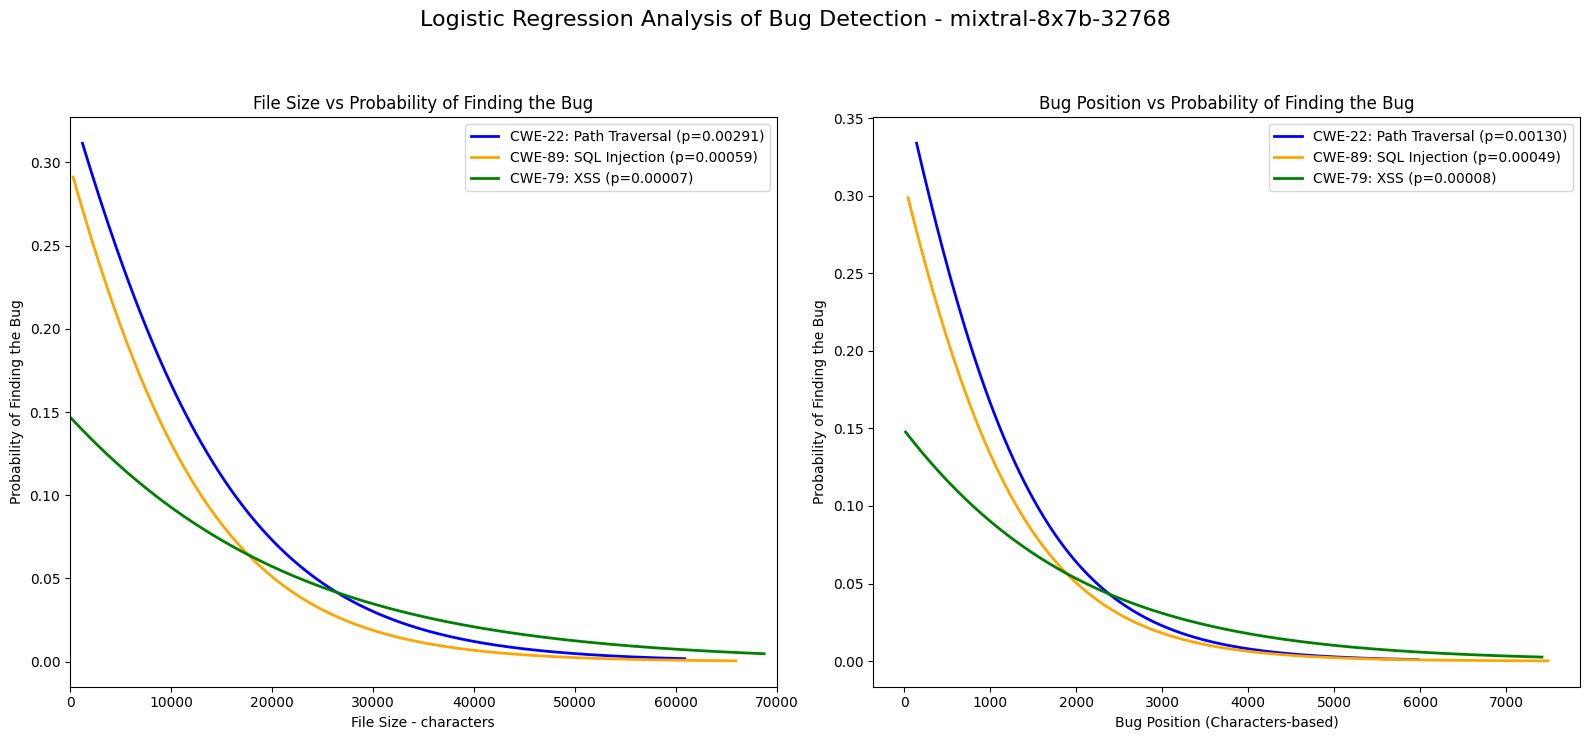

Missing file for CWE-22 with llama3-70b-8192
Missing file for CWE-89 with llama3-70b-8192
Data count mismatch: Expected 1086, got 654.
Some file_ids are missing the required number of entries in the data:
Results for CWE-79 with llama3-70b-8192
+---------------+------------+
| Metric        |      Value |
+===============+============+
| Total Samples | 654        |
+---------------+------------+
| Accuracy      |   0.24159  |
+---------------+------------+
| Precision     |   0.256484 |
+---------------+------------+
| Recall        |   0.272171 |
+---------------+------------+
| F1            |   0.264095 |
+---------------+------------+
Outliers for CWE-79 are below -444.5 or above 1513.5 1390.3100000000002


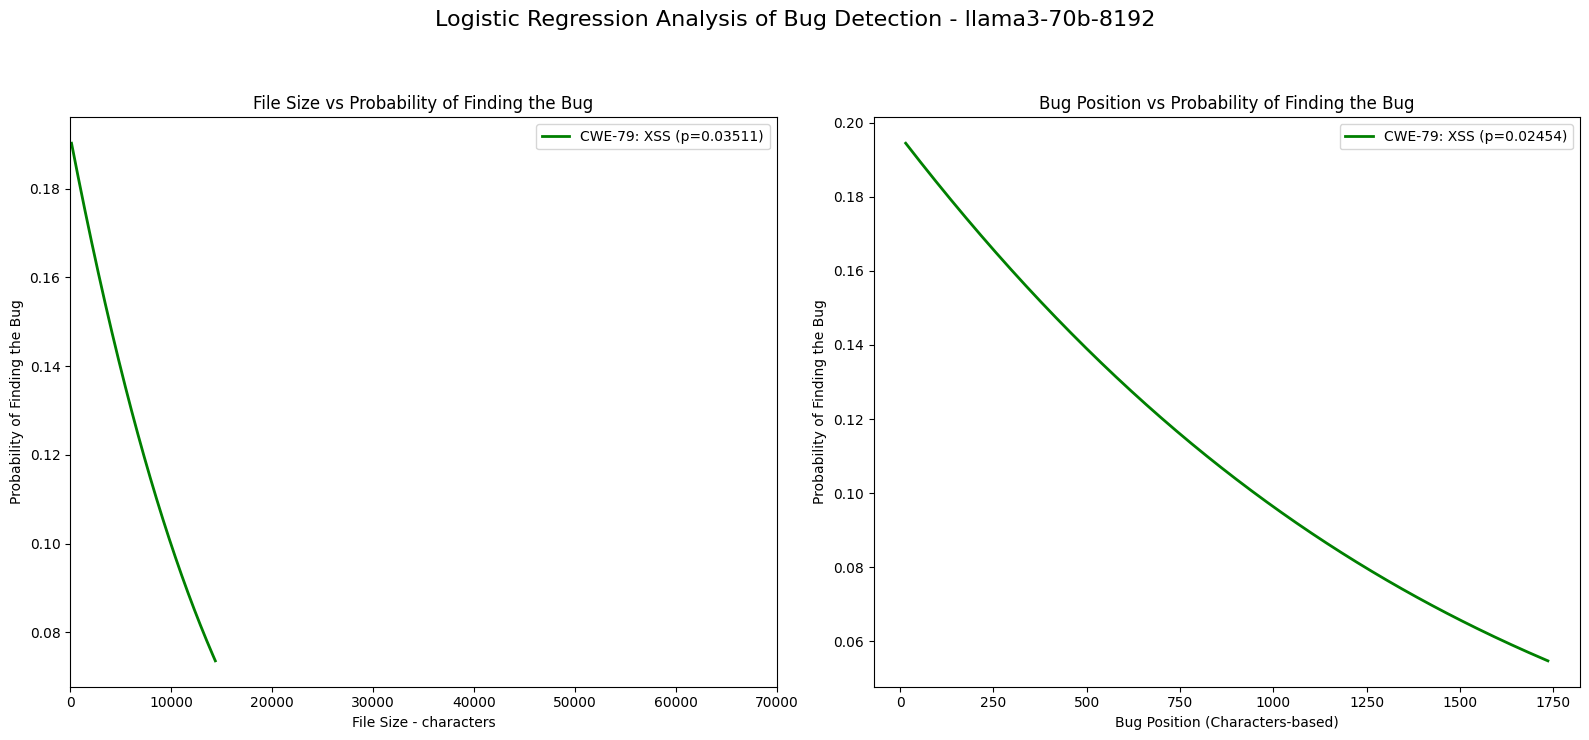

All file_ids have the correct number of entries.
Results for CWE-22 with gpt-4-turbo
+---------------+------------+
| Metric        |      Value |
+===============+============+
| Total Samples | 210        |
+---------------+------------+
| Accuracy      |   0.314286 |
+---------------+------------+
| Precision     |   0.378882 |
+---------------+------------+
| Recall        |   0.580952 |
+---------------+------------+
| F1            |   0.458647 |
+---------------+------------+
Outliers for CWE-22 are below -1555.125 or above 3817.875 5490.64
All file_ids have the correct number of entries.
Results for CWE-89 with gpt-4-turbo
+---------------+------------+
| Metric        |      Value |
+===============+============+
| Total Samples | 292        |
+---------------+------------+
| Accuracy      |   0.229452 |
+---------------+------------+
| Precision     |   0.305419 |
+---------------+------------+
| Recall        |   0.424658 |
+---------------+------------+
| F1            |   

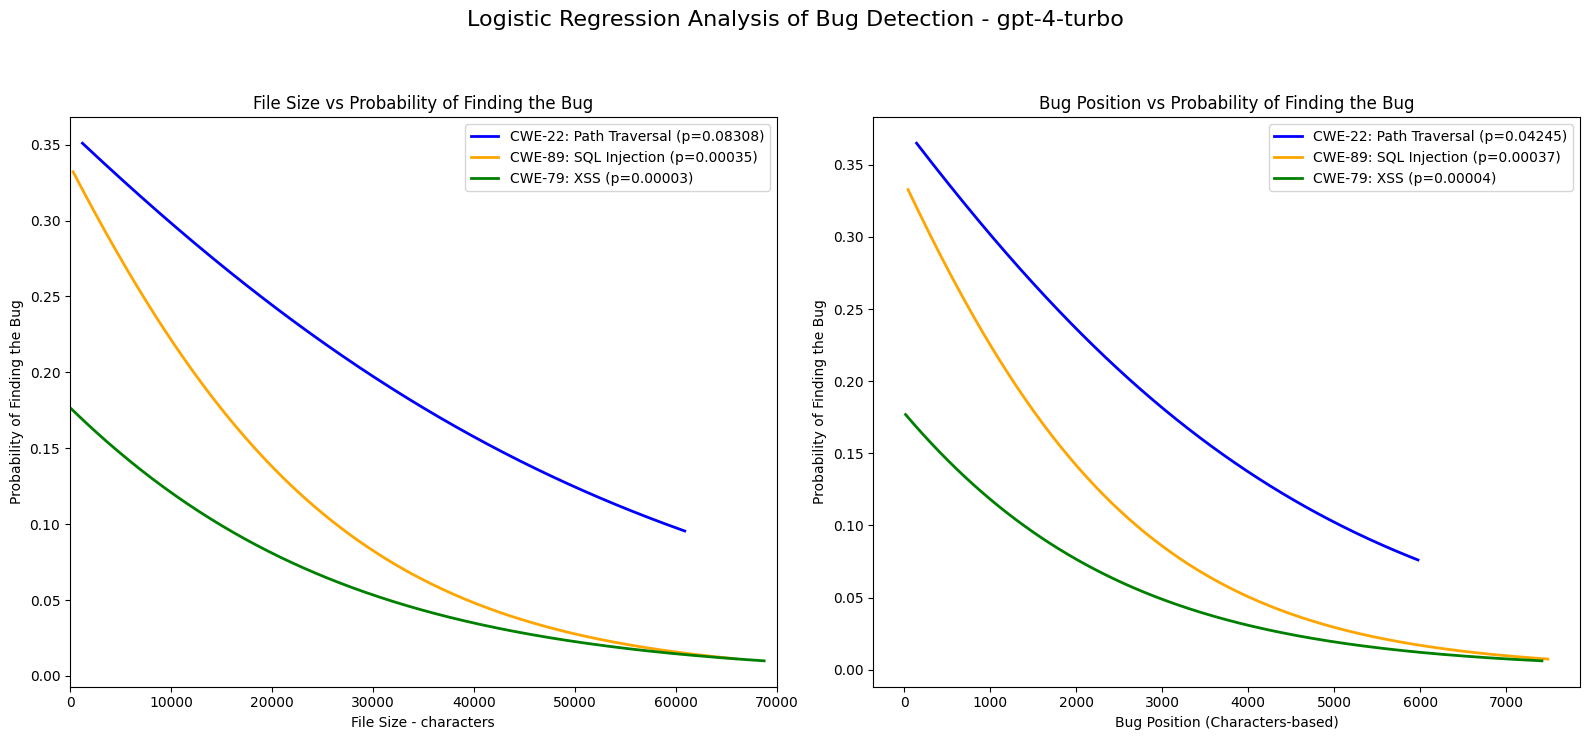

Data count mismatch: Expected 210, got 208.
Some file_ids are missing the required number of entries in the data:
Results for CWE-22 with gpt-3.5-turbo
+---------------+------------+
| Metric        |      Value |
+===============+============+
| Total Samples | 208        |
+---------------+------------+
| Accuracy      |   0.211538 |
+---------------+------------+
| Precision     |   0.291667 |
+---------------+------------+
| Recall        |   0.403846 |
+---------------+------------+
| F1            |   0.33871  |
+---------------+------------+
Outliers for CWE-22 are below -1538.625 or above 3786.375 4953.71
Data count mismatch: Expected 292, got 286.
Some file_ids are missing the required number of entries in the data:
Results for CWE-89 with gpt-3.5-turbo
+---------------+------------+
| Metric        |      Value |
+===============+============+
| Total Samples | 286        |
+---------------+------------+
| Accuracy      |   0.244755 |
+---------------+------------+
| Precisio

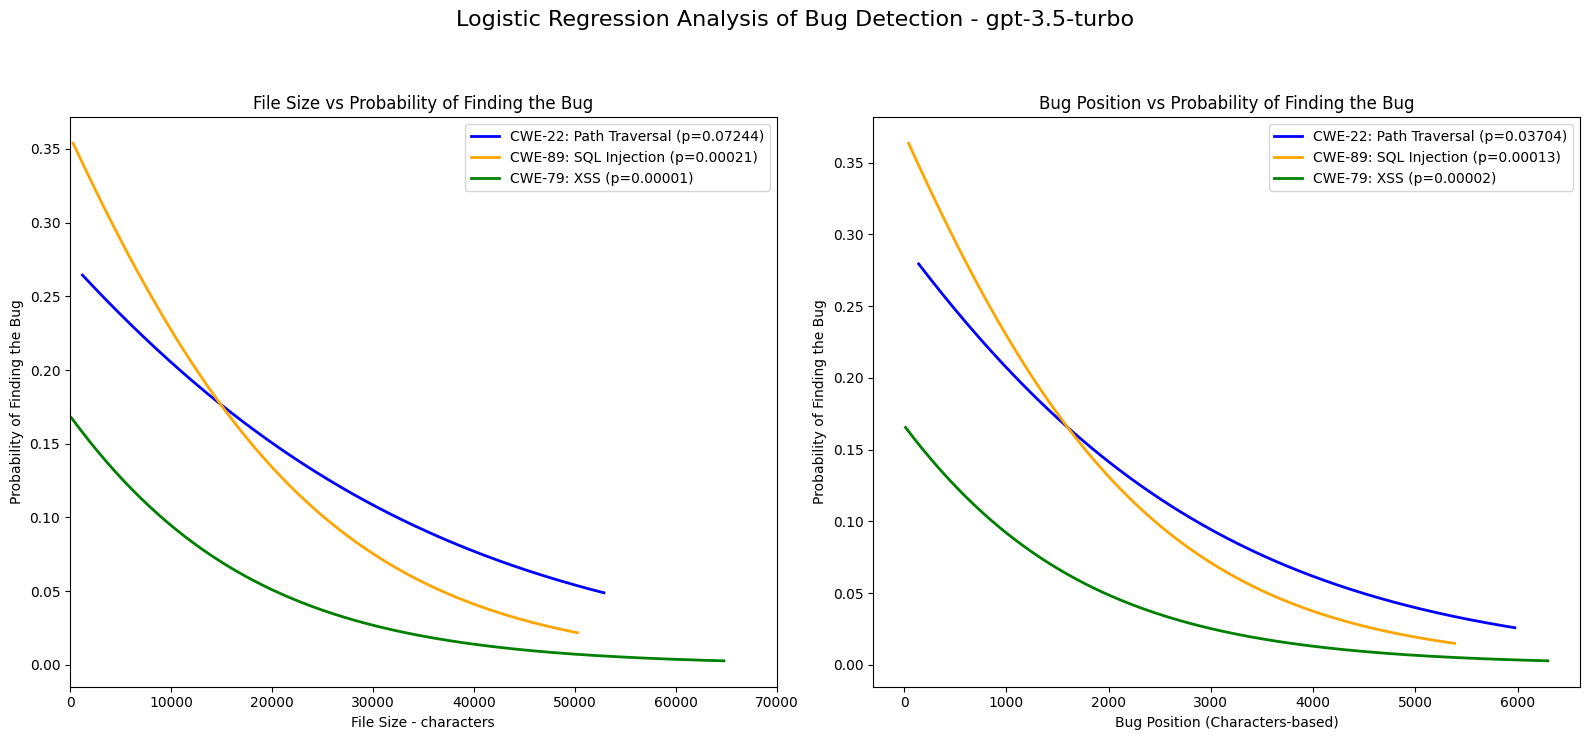

In [177]:
main()

In [178]:
# TESTING

# manual testing of one loop -> good for comparing responses and patch on given CWE (in jupyter variables)
# df = import_csv('CWE-22', 'llama3-70b-8192')
# df = import_csv('CWE-22', 'gpt-3.5-turbo')
# df = prepare_df(df)
# df['bug_pos']
# calculate_outlier_thresholds(df['bug_pos'])
# calculate_stats(df)

# fur for each models and for each CWE, then merge the DF togehter
total_df = pd.DataFrame()
for model in models:
    for cwe in cwes:
        try:
            df = import_csv(cwe, model)
            df = prepare_df(df)
            # add column with model and cwe
            df['model'] = model
            df['cwe'] = cwe
            total_df = pd.concat([total_df, df])
        except FileNotFoundError:
            print(f"Missing file for {cwe} with {model}")
# export to excel
total_df.to_excel('total_df.xlsx')

# # extract model gpt-3.5-turbo
# # groupt by CWE
# # showcount of values where coherent is true
# df = total_df[total_df['model'] == 'gpt-3.5-turbo']
# df = df.groupby('cwe')['coherent'].value_counts().unstack().fillna(0)
# # difive values by 2
# df = df / 2
# print(df)


All file_ids have the correct number of entries.
Data count mismatch: Expected 292, got 287.
Some file_ids are missing the required number of entries in the data:
Data count mismatch: Expected 1086, got 1084.
Some file_ids are missing the required number of entries in the data:
Missing file for CWE-22 with llama3-70b-8192
Missing file for CWE-89 with llama3-70b-8192
Data count mismatch: Expected 1086, got 654.
Some file_ids are missing the required number of entries in the data:
All file_ids have the correct number of entries.
All file_ids have the correct number of entries.
All file_ids have the correct number of entries.
Data count mismatch: Expected 210, got 208.
Some file_ids are missing the required number of entries in the data:
Data count mismatch: Expected 292, got 286.
Some file_ids are missing the required number of entries in the data:
Data count mismatch: Expected 1086, got 1061.
Some file_ids are missing the required number of entries in the data:
